[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/navjotts/ML-experiments/blob/master/20%20-%20Clustering%20text%20documents/Clustering_text_documents.ipynb)

## Clustering

Clustering is commonly used to create classifications for written text using Natural Language Processing NLP techniques.

A clustering approach allows classes to be generated automatically, grouping each document into like clusters. Then, researchers may fit the clustering to specific documents that they wish to get better insight into. Any document that shares a cluster with the tagged documents of interest then becomes a document of interest.

---

In this exercise, we will do feature extraction and clustering on a collection of newgroup documents.

In [2]:
import numpy as np
from sklearn.datasets import fetch_20newsgroups

dataset = fetch_20newsgroups(subset='all', shuffle=True)
print("%d documents" % len(dataset.data))
print("%d categories" % len(dataset.target_names))

18846 documents
20 categories


In [5]:
labels = dataset.target
print('Dataset example:')
print(dataset.data[0])

Dataset example:
From: Mamatha Devineni Ratnam <mr47+@andrew.cmu.edu>
Subject: Pens fans reactions
Organization: Post Office, Carnegie Mellon, Pittsburgh, PA
Lines: 12
NNTP-Posting-Host: po4.andrew.cmu.edu



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!




In [6]:
true_k = np.unique(labels).shape[0]
true_k

20

## Feature Extraction

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

n_features = 10000
vectorizer = TfidfVectorizer(max_df=0.5, 
                             max_features=n_features,
                             min_df=2, 
                             stop_words='english',
                             use_idf=True)

X = vectorizer.fit_transform(dataset.data)
print("n_samples: %d, n_features: %d" % X.shape)

n_samples: 18846, n_features: 10000


## KMeans v/s MiniBatchKMeans

[MiniBatchKmeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html) - MiniBatch means to use a smaller subset of the data over a few passes and average their results. MiniBatch has a shorter runtime than full KMeans and can actually complete on very-large datasets.

In [0]:
from time import time
from sklearn import metrics

def benchmark_clustering(estimator, name, data, labels):
  t0 = time()
  estimator.fit(data)
  print("%-9s\t%0.2f\t%i\t%0.3f\t%0.3f\t%0.3f\t%0.3f\t%0.3f\t%0.3f" %
        (name,
        time()-t0,
        estimator.inertia_,
        metrics.homogeneity_score(labels, estimator.labels_),
        metrics.completeness_score(labels, estimator.labels_),
        metrics.v_measure_score(labels, estimator.labels_),
        metrics.adjusted_rand_score(labels, estimator.labels_),
        metrics.adjusted_mutual_info_score(labels, estimator.labels_),
        metrics.silhouette_score(data, estimator.labels_, metric='euclidean', sample_size=1000)))

In [15]:
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans

print(100 * '_')
print('init\t\ttime\tinertia\thomo\tcompl\tv-meas\tARI\tAMI\tsilhouette')

benchmark_clustering(KMeans(init='k-means++', n_clusters=true_k, n_init=1, max_iter=100),
                     'KMeans', 
                     X, 
                     labels)

benchmark_clustering(MiniBatchKMeans(init='k-means++', n_clusters=true_k, n_init=1, batch_size=1000, init_size=1000), 
                     'MiniBatchKMeans', 
                     X, 
                     labels)

print(100 * '_')

____________________________________________________________________________________________________
init		time	inertia	homo	compl	v-meas	ARI	AMI	silhouette
KMeans   	44.76	17969	0.315	0.390	0.349	0.122	0.313	0.007
MiniBatchKMeans	0.70	18032	0.295	0.375	0.330	0.119	0.293	0.006
____________________________________________________________________________________________________


**Observation:** MiniBatchKMeans seems to be much faster, but drops in accuracy a bit in each of the metrics

## Let's try different values of `k` to see if we can determine the optimal number of clusters

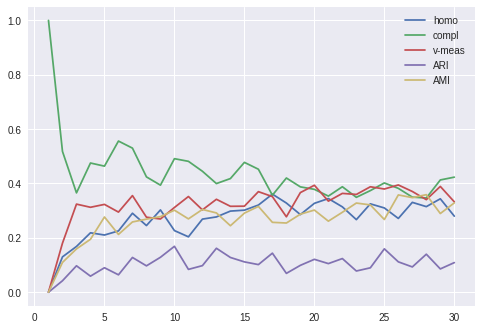

In [16]:
import matplotlib.pyplot as plt

k_vals = np.arange(1, 31)

metrics_scores = []
for each_k in k_vals:  
  kmini = MiniBatchKMeans(init='k-means++', n_clusters=each_k, n_init=1, max_iter=100, batch_size=1000, init_size=1000)
  kmini.fit(X)
  metrics_scores.append(metrics.homogeneity_score(labels, kmini.labels_))
plt.plot(k_vals, metrics_scores, label="homo")

metrics_scores = []
for each_k in k_vals:  
  kmini = MiniBatchKMeans(init='k-means++', n_clusters=each_k, n_init=1, max_iter=100, batch_size=1000, init_size=1000)
  kmini.fit(X)
  metrics_scores.append(metrics.completeness_score(labels, kmini.labels_))
plt.plot(k_vals, metrics_scores, label="compl")

metrics_scores = []
for each_k in k_vals:  
  kmini = MiniBatchKMeans(init='k-means++', n_clusters=each_k, n_init=1, max_iter=100, batch_size=1000, init_size=1000)
  kmini.fit(X)
  metrics_scores.append(metrics.v_measure_score(labels, kmini.labels_))
plt.plot(k_vals, metrics_scores, label="v-meas")

metrics_scores = []
for each_k in k_vals:  
  kmini = MiniBatchKMeans(init='k-means++', n_clusters=each_k, n_init=1, max_iter=100, batch_size=1000, init_size=1000)
  kmini.fit(X)
  metrics_scores.append(metrics.adjusted_rand_score(labels, kmini.labels_))
plt.plot(k_vals, metrics_scores, label="ARI")

metrics_scores = []
for each_k in k_vals:  
  kmini = MiniBatchKMeans(init='k-means++', n_clusters=each_k, n_init=1, max_iter=100, batch_size=1000, init_size=1000)
  kmini.fit(X)
  metrics_scores.append(metrics.adjusted_mutual_info_score(labels, kmini.labels_))
plt.plot(k_vals, metrics_scores, label="AMI")

plt.legend();

**Observation:**

1.   Homogeneity does maximize at k=20 (the original `true_k`)
2.   The other metrics don't really maximize but are on the *optimal* side at k=20


## Is clustering working? Let's check

In [17]:
kmini = MiniBatchKMeans(init='k-means++', n_clusters=true_k, n_init=1, max_iter=100, batch_size=1000, init_size=1000)
kmini.fit(X)

MiniBatchKMeans(batch_size=1000, compute_labels=True, init='k-means++',
        init_size=1000, max_iter=100, max_no_improvement=10, n_clusters=20,
        n_init=1, random_state=None, reassignment_ratio=0.01, tol=0.0,
        verbose=0)

In [18]:
prediction = kmini.predict(X[0])
print(prediction)
print(dataset.data[0])

[19]
From: Mamatha Devineni Ratnam <mr47+@andrew.cmu.edu>
Subject: Pens fans reactions
Organization: Post Office, Carnegie Mellon, Pittsburgh, PA
Lines: 12
NNTP-Posting-Host: po4.andrew.cmu.edu



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!




Let's see the predictions for the 1st 50 documents

In [19]:
print(kmini.predict(X[0:50]))

[19  0 15  9  9 10  3 19 19  3 10  4 16  3 16 15 12  3 16 12 10  7  6  3
 19 10 16  3  0 16 10 10 13  3  3  3 11  3  3 10  3  3  3 10  3  0 13 11
  4  3]


We want to pull out all the documents belonging to cluster [19] from the 1st 50 documents

In [20]:
kmini.predict(X[0:50])==prediction

array([ True, False, False, False, False, False, False,  True,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False])

In [21]:
required_indexes = np.arange(0, 50)[kmini.predict(X[0:50])==prediction]
required_indexes

array([ 0,  7,  8, 24])

In [22]:
for i in required_indexes:
  print(i)
  print(dataset.data[i])
  print(100 * '-')

0
From: Mamatha Devineni Ratnam <mr47+@andrew.cmu.edu>
Subject: Pens fans reactions
Organization: Post Office, Carnegie Mellon, Pittsburgh, PA
Lines: 12
NNTP-Posting-Host: po4.andrew.cmu.edu



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!


-----------------------------------------------------------------------------------------------

**Observation:** yup, clustering seems to be working, all 4 documents in the top 50 having the cluster [19] seems to be related to 'Hockey' – which is related to the `rec.sport.hockey` category of the dataset